In [1]:
import pandas as pd

df = pd.read_csv("Dim.Fact_Customer_Churn_sql.csv")

In [2]:
print(df['Total_Charges_INR'].dtype)

float64


In [3]:
print(df['Total_Charges_INR'].isnull().sum())

0


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
print(df.columns)

Index(['Fact_ID', 'Customer_ID', 'Date_ID', 'Contract_ID',
       'Internet_Service_ID', 'Payment_ID', 'Geography_ID', 'Plan_ID',
       'Monthly_Charges_INR', 'Total_Charges_INR', 'Tenure_Months',
       'Churn_Flag', 'Revenue_INR', 'CLV_INR', 'Support_Tickets',
       'Avg_Monthly_Usage_GB'],
      dtype='object')


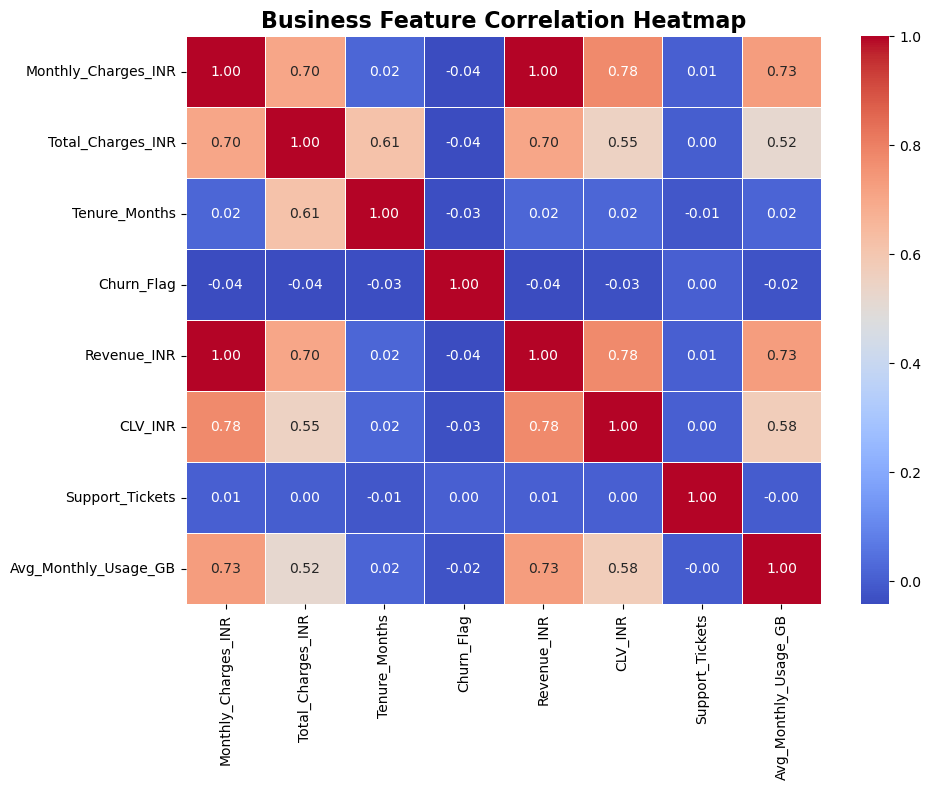

In [6]:
# Keep only meaningful business columns
analysis_df = df[['Monthly_Charges_INR',
                  'Total_Charges_INR',
                  'Tenure_Months',
                  'Churn_Flag',
                  'Revenue_INR',
                  'CLV_INR',
                  'Support_Tickets',
                  'Avg_Monthly_Usage_GB']]

corr_matrix = analysis_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Business Feature Correlation Heatmap",
          fontsize=16,
          fontweight='bold')

plt.tight_layout()
plt.show()

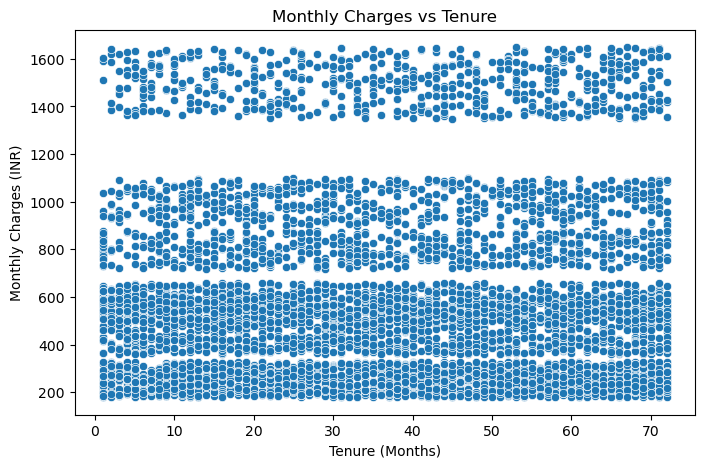

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Tenure_Months',
    y='Monthly_Charges_INR',
    data=df
)

plt.title("Monthly Charges vs Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges (INR)")
plt.show()

In [8]:
df[['Monthly_Charges_INR','Tenure_Months']].corr()

,Monthly_Charges_INR,Tenure_Months
Monthly_Charges_INR,1.000000,0.019846
Tenure_Months,0.019846,1.000000


In [9]:
corr_with_churn = analysis_df.corr()['Churn_Flag'].sort_values(ascending=False)

print(corr_with_churn)

Churn_Flag              1.000000
Support_Tickets         0.003145
Avg_Monthly_Usage_GB   -0.022378
CLV_INR                -0.033178
Tenure_Months          -0.034599
Total_Charges_INR      -0.039995
Revenue_INR            -0.041614
Monthly_Charges_INR    -0.041614
Name: Churn_Flag, dtype: float64


In [10]:
business_df = df[['Monthly_Charges_INR',
                  'Total_Charges_INR',
                  'Tenure_Months',
                  'Churn_Flag',
                  'Revenue_INR',
                  'CLV_INR',
                  'Support_Tickets',
                  'Avg_Monthly_Usage_GB']]

corr_with_churn = business_df.corr()['Churn_Flag'].sort_values(ascending=False)

print(corr_with_churn)

Churn_Flag              1.000000
Support_Tickets         0.003145
Avg_Monthly_Usage_GB   -0.022378
CLV_INR                -0.033178
Tenure_Months          -0.034599
Total_Charges_INR      -0.039995
Revenue_INR            -0.041614
Monthly_Charges_INR    -0.041614
Name: Churn_Flag, dtype: float64


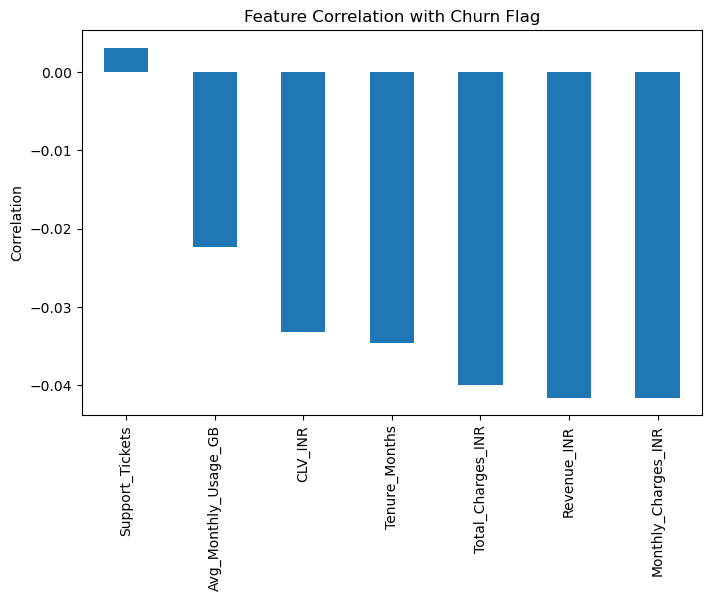

In [11]:
plt.figure(figsize=(8,5))

corr_with_churn.drop('Churn_Flag').plot(kind='bar')

plt.title('Feature Correlation with Churn Flag')
plt.ylabel('Correlation')
plt.show()

In [12]:
 ## Day 12
print(df.columns.tolist())

['Fact_ID', 'Customer_ID', 'Date_ID', 'Contract_ID', 'Internet_Service_ID', 'Payment_ID', 'Geography_ID', 'Plan_ID', 'Monthly_Charges_INR', 'Total_Charges_INR', 'Tenure_Months', 'Churn_Flag', 'Revenue_INR', 'CLV_INR', 'Support_Tickets', 'Avg_Monthly_Usage_GB']


In [13]:
df.columns

Index(['Fact_ID', 'Customer_ID', 'Date_ID', 'Contract_ID',
       'Internet_Service_ID', 'Payment_ID', 'Geography_ID', 'Plan_ID',
       'Monthly_Charges_INR', 'Total_Charges_INR', 'Tenure_Months',
       'Churn_Flag', 'Revenue_INR', 'CLV_INR', 'Support_Tickets',
       'Avg_Monthly_Usage_GB'],
      dtype='object')

In [38]:
X = df.drop('Churn_Flag', axis=1)
y = df['Churn_Flag']

In [39]:
df = df.dropna()

In [40]:
print(df.isnull().sum().sum())

0


In [41]:
X = df.drop('Churn_Flag', axis=1)
y = df['Churn_Flag']

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [45]:
y_pred = model.predict(X_test_scaled)

In [46]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8081149619611158
F1 Score: 0.0


In [47]:
print(df['Churn_Flag'].value_counts())

Churn_Flag
0.0    4781
1.0    1133
Name: count, dtype: int64


In [48]:
print(df['Churn_Flag'].value_counts())

Churn_Flag
0.0    4781
1.0    1133
Name: count, dtype: int64


In [49]:
print(y_pred)

[0. 0. 0. ... 0. 0. 0.]


In [50]:
import numpy as np
print(np.unique(y_pred, return_counts=True))

(array([0.]), array([1183], dtype=int64))


In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [52]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6339814032121724
F1 Score: 0.4203480589022758


In [53]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[593 363]
 [ 70 157]]


In [54]:
print(df['Churn_Flag'].value_counts())

Churn_Flag
0.0    4781
1.0    1133
Name: count, dtype: int64


In [55]:
print(df['Churn_Flag'].value_counts())

Churn_Flag
0.0    4781
1.0    1133
Name: count, dtype: int64


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.62      0.73       956
         1.0       0.30      0.69      0.42       227

    accuracy                           0.63      1183
   macro avg       0.60      0.66      0.58      1183
weighted avg       0.78      0.63      0.67      1183



In [57]:
## day 13
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=3000),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV F1: 0.4218914950196657


In [58]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

         0.0       0.89      0.62      0.73       956
         1.0       0.30      0.69      0.42       227

    accuracy                           0.63      1183
   macro avg       0.60      0.65      0.58      1183
weighted avg       0.78      0.63      0.67      1183



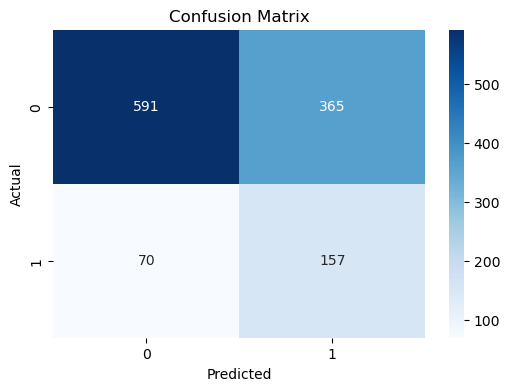

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
print(df.columns.tolist())

['Fact_ID', 'Customer_ID', 'Date_ID', 'Contract_ID', 'Internet_Service_ID', 'Payment_ID', 'Geography_ID', 'Plan_ID', 'Monthly_Charges_INR', 'Total_Charges_INR', 'Tenure_Months', 'Churn_Flag', 'Revenue_INR', 'CLV_INR', 'Support_Tickets', 'Avg_Monthly_Usage_GB']


In [61]:
df['CLV_Calculated'] = df['Monthly_Charges_INR'] * df['Tenure_Months']

df[['Customer_ID', 'CLV_Calculated']].head()

,Customer_ID,CLV_Calculated
0,1,86903.14
1,2,30625.35
2,3,31053.78
3,4,16149.24
4,5,53233.40


In [62]:
df[['Customer_ID', 'CLV_INR']].head()

,Customer_ID,CLV_INR
0,1,19505.06
1,2,58780.40
2,3,40004.67
3,4,7775.90
4,5,23126.13


In [63]:
churn_summary = df.groupby('Churn_Flag').agg({
    'Revenue_INR':'sum',
    'Customer_ID':'count'
}).rename(columns={'Customer_ID':'Customer_Count'})

churn_summary

,Revenue_INR,Customer_Count
Churn_Flag,,
0.0,2970516.70,4781
1.0,657764.07,1133


In [64]:
contract_summary = df.groupby('Contract_ID').agg({
    'Revenue_INR':'sum',
    'Customer_ID':'count'
}).rename(columns={'Customer_ID':'Customer_Count'})

contract_summary

,Revenue_INR,Customer_Count
Contract_ID,,
1,625120.40,1024
2,590194.66,965
3,596689.58,992
4,591274.66,975
5,641906.58,996
6,583094.89,962


In [65]:
X_scaled = scaler.transform(X)

churn_prob = model.predict_proba(X_scaled)[:, 1]

In [66]:
results = pd.DataFrame({
    'Customer_ID': df['Customer_ID'],
    'Churn_Probability': churn_prob
})

results.head()

,Customer_ID,Churn_Probability
0,1,0.177769
1,2,0.244898
2,3,0.297922
3,4,0.609393
4,5,0.552088


In [67]:
results.to_csv('churn_probabilities.csv', index=False)
print("Export Successful")


Export Successful


In [68]:
### DAy 18

df.columns

Index(['Fact_ID', 'Customer_ID', 'Date_ID', 'Contract_ID',
       'Internet_Service_ID', 'Payment_ID', 'Geography_ID', 'Plan_ID',
       'Monthly_Charges_INR', 'Total_Charges_INR', 'Tenure_Months',
       'Churn_Flag', 'Revenue_INR', 'CLV_INR', 'Support_Tickets',
       'Avg_Monthly_Usage_GB', 'CLV_Calculated'],
      dtype='object')

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5914 entries, 0 to 5913
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fact_ID               5914 non-null   int64  
 1   Customer_ID           5914 non-null   int64  
 2   Date_ID               5914 non-null   int64  
 3   Contract_ID           5914 non-null   int64  
 4   Internet_Service_ID   5914 non-null   int64  
 5   Payment_ID            5914 non-null   int64  
 6   Geography_ID          5914 non-null   int64  
 7   Plan_ID               5914 non-null   int64  
 8   Monthly_Charges_INR   5914 non-null   float64
 9   Total_Charges_INR     5914 non-null   float64
 10  Tenure_Months         5914 non-null   float64
 11  Churn_Flag            5914 non-null   float64
 12  Revenue_INR           5914 non-null   float64
 13  CLV_INR               5914 non-null   float64
 14  Support_Tickets       5914 non-null   float64
 15  Avg_Monthly_Usage_GB  5914

In [70]:
## Feature and target
X = df.drop('Churn_Flag', axis=1)
y = df['Churn_Flag']

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver='liblinear',
    max_iter=5000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [74]:
y_pred = model.predict(X_test_scaled)

In [75]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6331360946745562
              precision    recall  f1-score   support

         0.0       0.89      0.62      0.73       956
         1.0       0.30      0.69      0.42       227

    accuracy                           0.63      1183
   macro avg       0.60      0.66      0.58      1183
weighted avg       0.78      0.63      0.67      1183



In [76]:
X_scaled = scaler.transform(X)

df['Risk_Score'] = model.predict_proba(X_scaled)[:, 1]

In [77]:
def risk_level(score):
    if score >= 0.70:
        return "High Risk"
    elif score >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Risk_Level'] = df['Risk_Score'].apply(risk_level)

In [78]:
df[['Customer_ID', 'Churn_Flag', 'Risk_Score', 'Risk_Level']].head()

,Customer_ID,Churn_Flag,Risk_Score,Risk_Level
0,1,0.0,0.175717,Low Risk
1,2,0.0,0.239690,Low Risk
2,3,0.0,0.305261,Low Risk
3,4,1.0,0.610745,Medium Risk
4,5,0.0,0.546872,Medium Risk


In [79]:
df.to_csv("PowerBI_Risk_Output.csv", index=False)

print("File Exported Successfully")

File Exported Successfully
